In [39]:
# Check TensorFlow version
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [40]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

from tensorflow.keras.utils import to_categorical

from sklearn.metrics import accuracy_score

In [41]:
# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


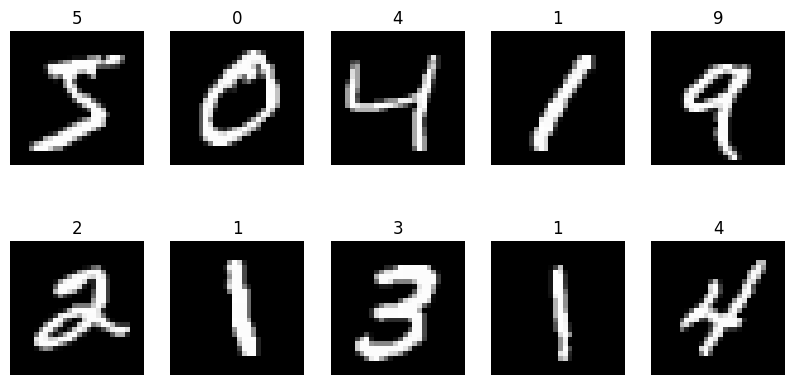

In [42]:
# Visualise sample handwritten digit images
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

In [43]:
# Normalise image pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [44]:
# Reshape images for CNN input
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [45]:
# Convert labels to one-hot encoded format
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print(y_train.shape)

(60000, 10)


In [46]:
# Create CNN model with one convolutional layer
model_1 = Sequential()

model_1.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model_1.add(MaxPooling2D((2,2)))

model_1.add(Flatten())

model_1.add(Dense(128, activation='relu'))

model_1.add(Dense(10, activation='softmax'))

In [47]:
# Display CNN1 architecture
model_1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Compile CNN1 model
model_1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [49]:
# Train CNN1 model
history_1 = model_1.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.9287 - loss: 0.2529 - val_accuracy: 0.9718 - val_loss: 0.1010
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9787 - loss: 0.0733 - val_accuracy: 0.9783 - val_loss: 0.0684
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9852 - loss: 0.0492 - val_accuracy: 0.9828 - val_loss: 0.0604
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9892 - loss: 0.0360 - val_accuracy: 0.9837 - val_loss: 0.0553
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9921 - loss: 0.0266 - val_accuracy: 0.9837 - val_loss: 0.0532


In [50]:
# Evaluate CNN1 performance
loss_1, acc_1 = model_1.evaluate(
    X_test,
    y_test
)

print("CNN Model 1 Accuracy:", acc_1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9852 - loss: 0.0436
CNN Model 1 Accuracy: 0.9851999878883362


In [51]:
# Create CNN model with two convolutional layers
model_2 = Sequential()

model_2.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model_2.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model_2.add(MaxPooling2D((2,2)))

model_2.add(Flatten())

model_2.add(Dense(128, activation='relu'))

model_2.add(Dense(10, activation='softmax'))

In [52]:
# Display CNN2 architecture
model_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# Compile CNN2 model
model_2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [54]:
# Train CNN2 model
history_2 = model_2.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 68s 180ms/step - accuracy: 0.9472 - loss: 0.1786 - val_accuracy: 0.9827 - val_loss: 0.0620
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 67s 179ms/step - accuracy: 0.9860 - loss: 0.0468 - val_accuracy: 0.9849 - val_loss: 0.0537
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 180ms/step - accuracy: 0.9906 - loss: 0.0300 - val_accuracy: 0.9847 - val_loss: 0.0521
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 179ms/step - accuracy: 0.9932 - loss: 0.0200 - val_accuracy: 0.9872 - val_loss: 0.0456
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 68s 181ms/step - accuracy: 0.9950 - loss: 0.0146 - val_accuracy: 0.9860 - val_loss: 0.0503


In [55]:
# Evaluate CNN2 performance
loss_2, acc_2 = model_2.evaluate(
    X_test,
    y_test
)

print("CNN Model 2 Accuracy:", acc_2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9887 - loss: 0.0366
CNN Model 2 Accuracy: 0.9886999726295471


In [56]:
# Create CNN model with three convolutional layers
model_3 = Sequential()

model_3.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model_3.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model_3.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model_3.add(MaxPooling2D((2,2)))

model_3.add(Flatten())

model_3.add(Dense(128, activation='relu'))

model_3.add(Dense(10, activation='softmax'))

In [57]:
# Compile CNN3 model
model_3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [58]:
# Train CNN3 model
history_3 = model_3.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 221s 586ms/step - accuracy: 0.9544 - loss: 0.1516 - val_accuracy: 0.9797 - val_loss: 0.0626
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 267s 601ms/step - accuracy: 0.9875 - loss: 0.0400 - val_accuracy: 0.9849 - val_loss: 0.0496
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 257s 588ms/step - accuracy: 0.9918 - loss: 0.0256 - val_accuracy: 0.9895 - val_loss: 0.0382
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 259s 581ms/step - accuracy: 0.9940 - loss: 0.0171 - val_accuracy: 0.9863 - val_loss: 0.0477
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 264s 586ms/step - accuracy: 0.9959 - loss: 0.0126 - val_accuracy: 0.9892 - val_loss: 0.0447


In [59]:
# Evaluate CNN3 performance
loss_3, acc_3 = model_3.evaluate(
    X_test,
    y_test
)

print("CNN Model 3 Accuracy:", acc_3)

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.9885 - loss: 0.0377
CNN Model 3 Accuracy: 0.9884999990463257


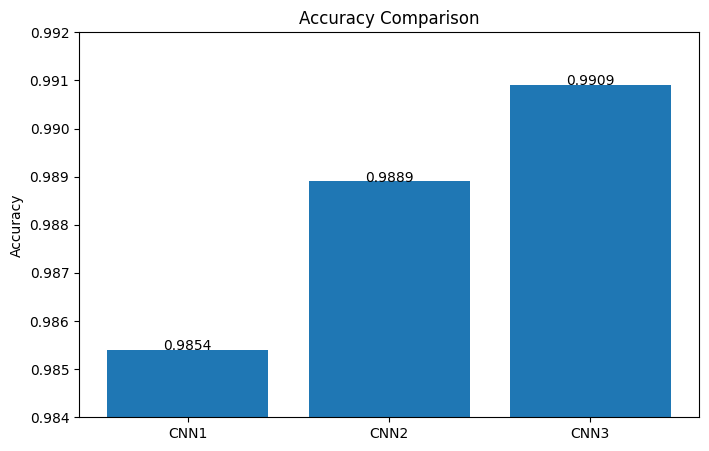

In [60]:
# Compare classification accuracy across models
plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies)

plt.ylim(0.984,0.992)

plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.4f}',
        ha='center'
    )

plt.show()

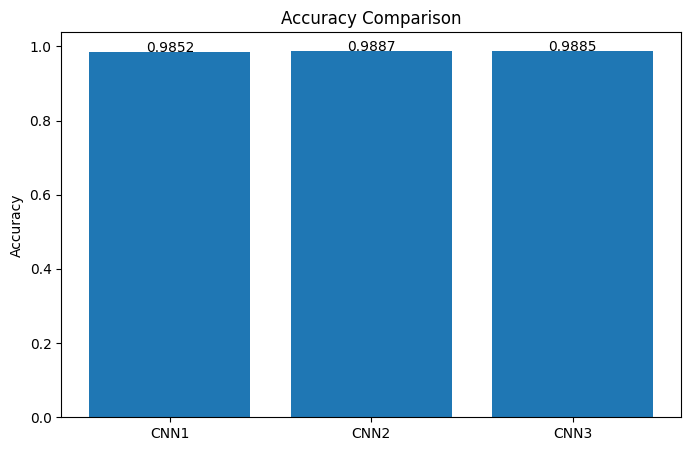

In [61]:
# Display accuracy comparison bar chart
models = ['CNN1', 'CNN2', 'CNN3']
accuracies = [acc_1, acc_2, acc_3]

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.4f}',
        ha='center'
    )

plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')

plt.show()

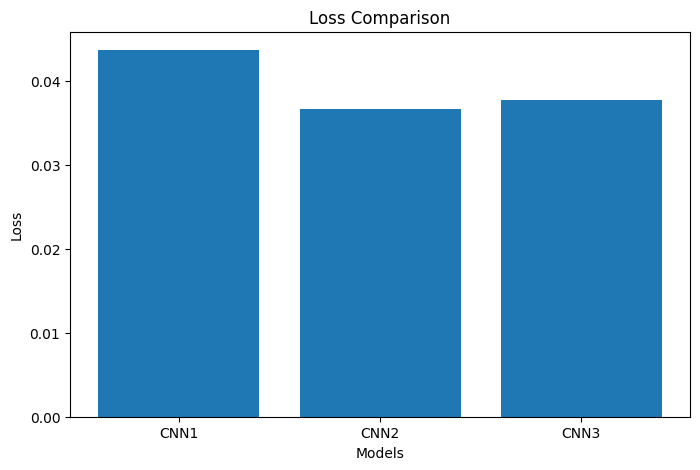

In [62]:
# Compare loss values across models
losses = [loss_1, loss_2, loss_3]

plt.figure(figsize=(8,5))

plt.bar(models, losses)

plt.title('Loss Comparison')
plt.xlabel('Models')
plt.ylabel('Loss')

plt.show()

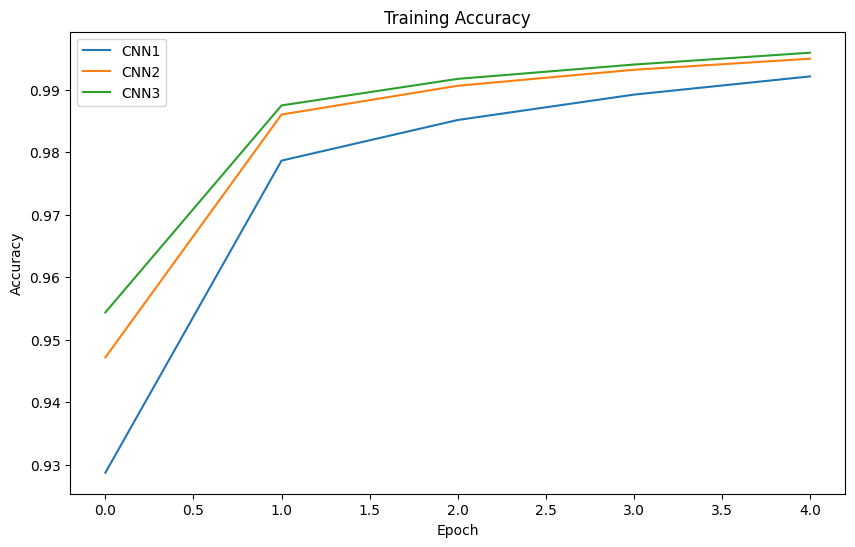

In [63]:
# Display training accuracy over epochs
plt.figure(figsize=(10,6))

plt.plot(
    history_1.history['accuracy'],
    label='CNN1'
)

plt.plot(
    history_2.history['accuracy'],
    label='CNN2'
)

plt.plot(
    history_3.history['accuracy'],
    label='CNN3'
)

plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

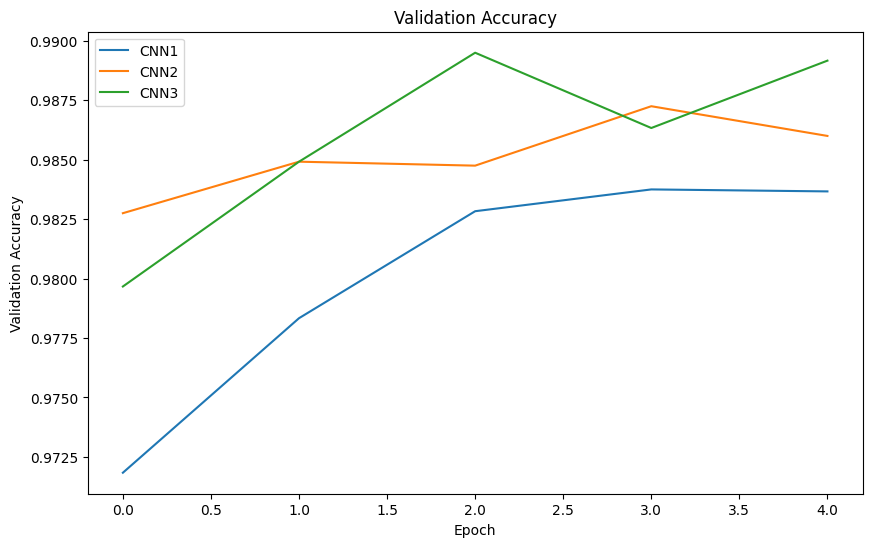

In [64]:
# Display validation accuracy over epochs
plt.figure(figsize=(10,6))

plt.plot(
    history_1.history['val_accuracy'],
    label='CNN1'
)

plt.plot(
    history_2.history['val_accuracy'],
    label='CNN2'
)

plt.plot(
    history_3.history['val_accuracy'],
    label='CNN3'
)

plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')

plt.legend()

plt.show()

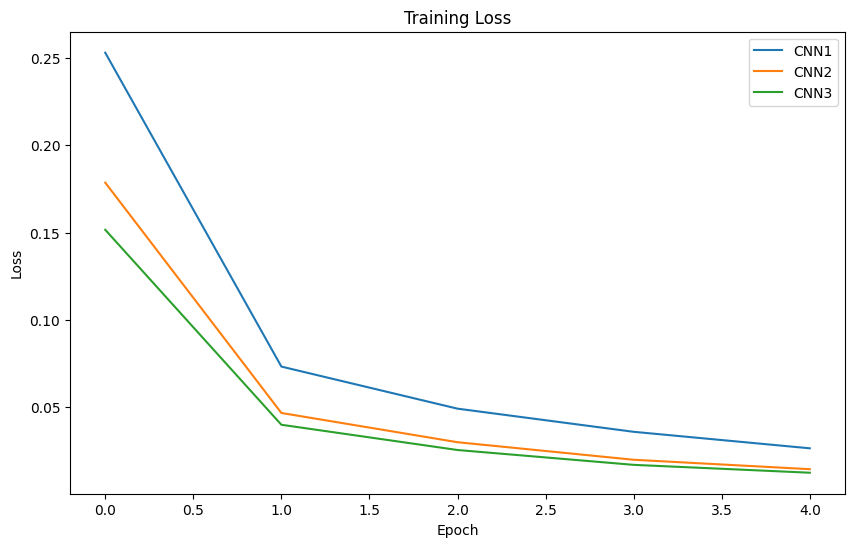

In [65]:

# Display training loss over epochs
plt.figure(figsize=(10,6))

plt.plot(
    history_1.history['loss'],
    label='CNN1'
)

plt.plot(
    history_2.history['loss'],
    label='CNN2'
)

plt.plot(
    history_3.history['loss'],
    label='CNN3'
)

plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

In [66]:
# Display model architecture summaries
model_1.summary()
model_2.summary()
model_3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,081,888 (7.94 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 22, 22, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     1,982,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,229,664 (23.76 MB)

 Trainable params: 2,076,554 (7.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,153,110 (15.84 MB)